# *Sathwik TV*
# *Data Science Intern — Oasis Infobyte*
# *Task: Iris Flower Classification*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('C:\\DS\\CodeSoft\\IRIS\\IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df.duplicated().sum()   

np.int64(3)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**EDA**

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


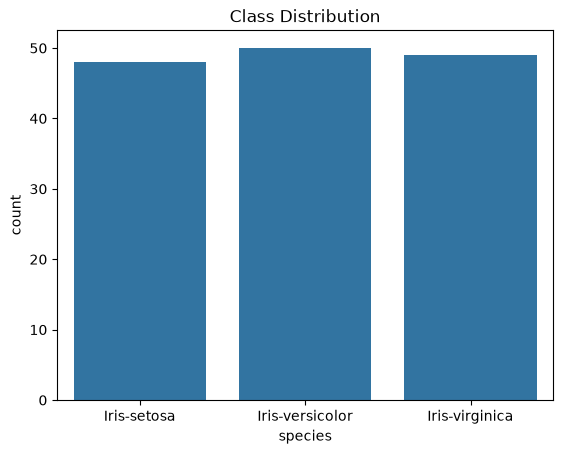

In [10]:
# Class distribution
print(df['species'].value_counts())
sns.countplot(data=df, x='species')
plt.title('Class Distribution')
plt.show()

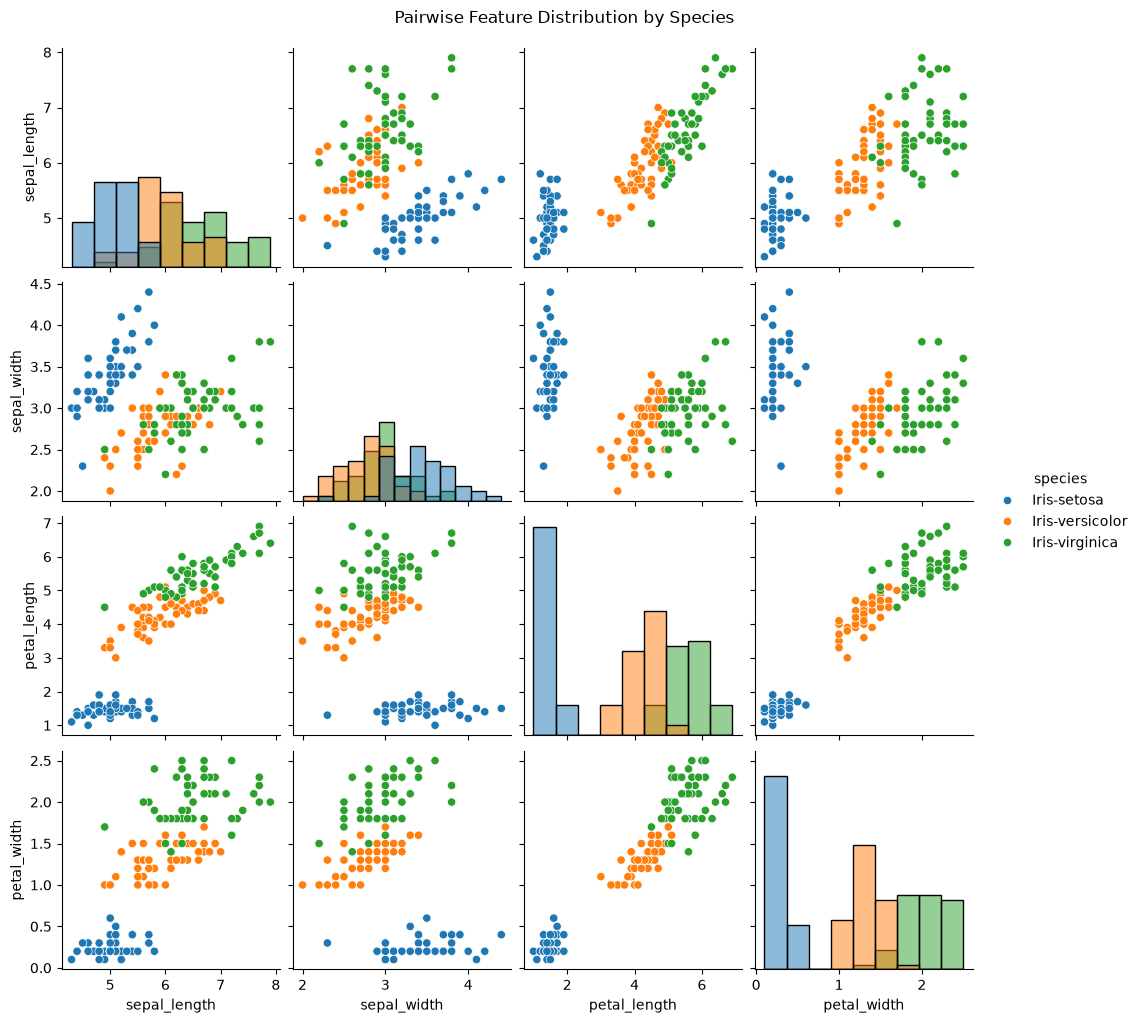

In [11]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Pairwise Feature Distribution by Species', y=1.02)
plt.show()

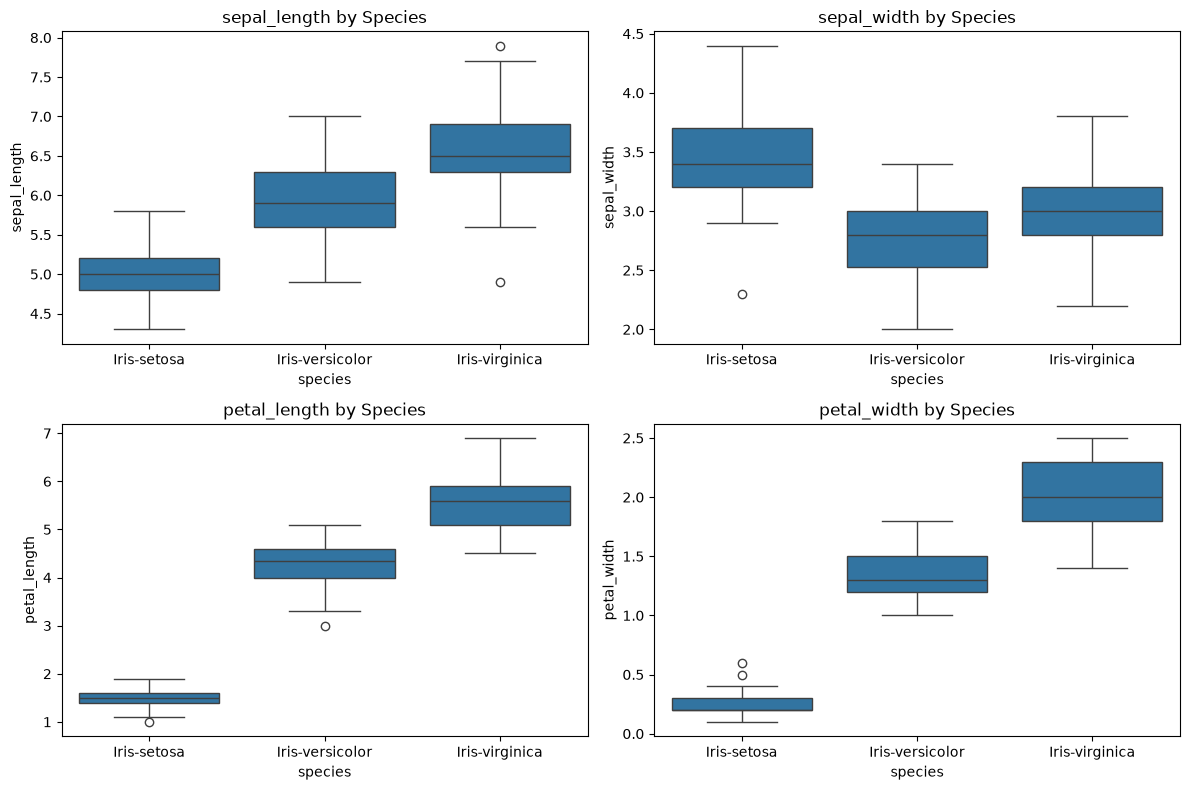

In [12]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

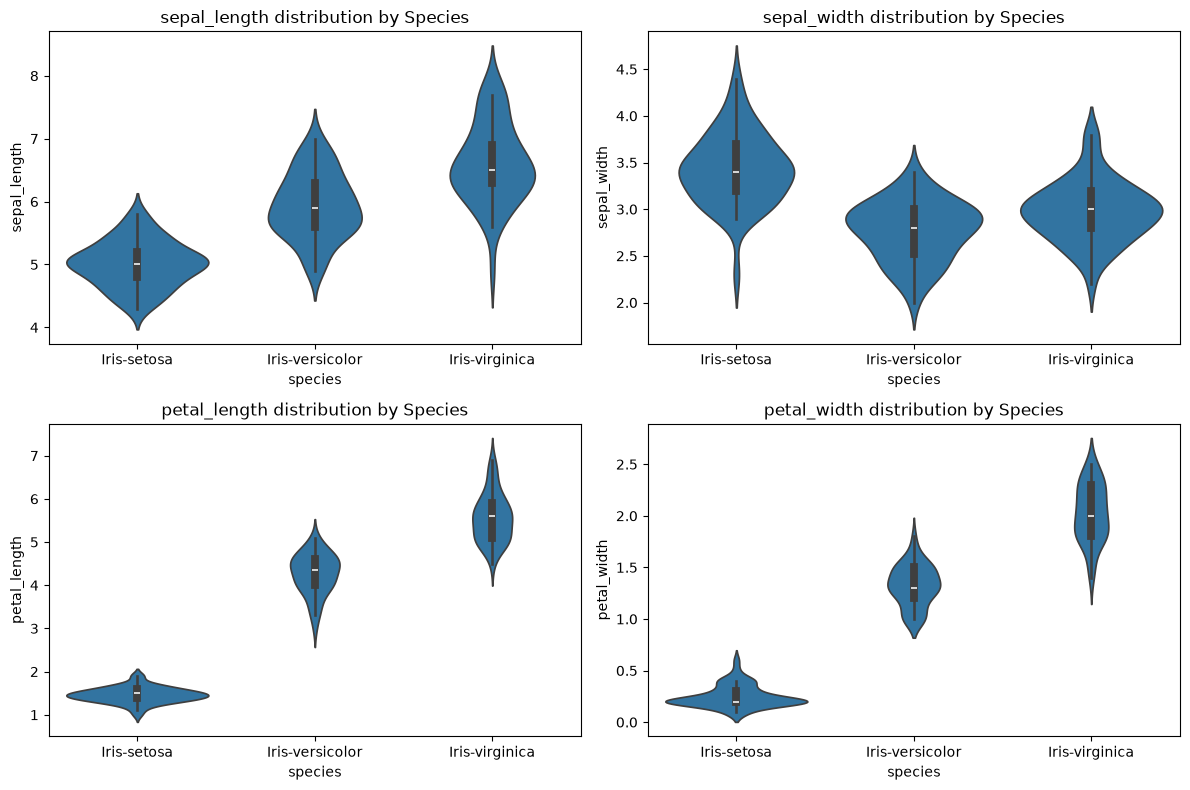

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features):
    sns.violinplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'{feature} distribution by Species')
plt.tight_layout()
plt.show()

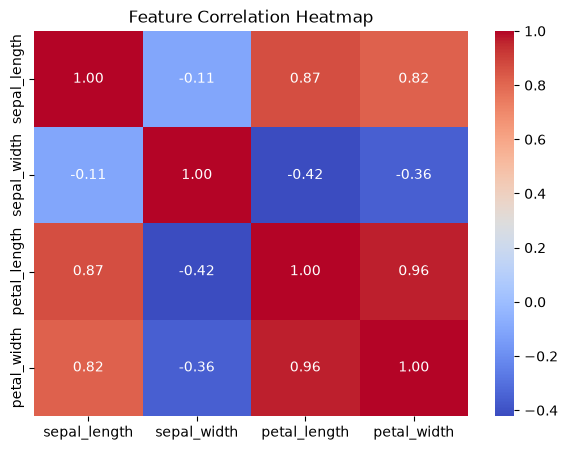

In [14]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

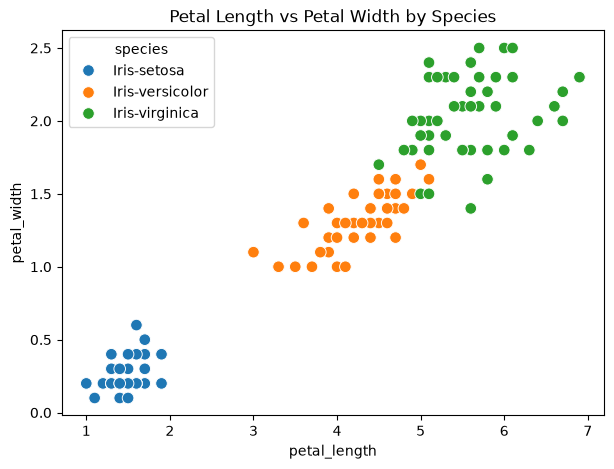

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=70)
plt.title('Petal Length vs Petal Width by Species')
plt.show()

**Feature Selection Discussion**

Looking at the petal length vs petal width scatter plot, the species basically sort themselves into clean clusters — setosa is fully separated from the other two just by petal size, while versicolor and virginica overlap a bit more but are still far more distinguishable on petals than on sepals. Petal length and petal width are also strongly correlated (~0.96), so they're carrying similar information — not a real problem with just 4 features, but worth noting. Overall, petal measurements look like the strongest predictors here.

**PREPROCESSING**

In [16]:
FEATURES = df.select_dtypes(include=np.number).columns.tolist()
TARGET = 'species'   # single column name, not a list

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

x=df[FEATURES]
y=df[TARGET]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)


**MODEL:**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


FEATURES_trans = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', FEATURES_trans, FEATURES )    
])

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=200))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report,confusion_matrix
LG = logreg_pipeline.fit(x_train, y_train)
LG_pred = LG.predict(x_test)

Accuracy = accuracy_score(y_test, LG_pred)
F1 = f1_score(y_test, LG_pred, average='macro')
PREC = precision_score(y_test, LG_pred, average='macro')
RECALL = recall_score(y_test, LG_pred, average='macro')

print("Accuracy:", Accuracy)
print("F1 score:", F1)
print("Precision:", PREC)
print("Recall:", RECALL)
print("classification report:\n", classification_report(y_test, LG_pred))

print (confusion_matrix(y_test, LG_pred))

Accuracy: 0.9333333333333333
F1 score: 0.9333333333333332
Precision: 0.9333333333333332
Recall: 0.9333333333333332
classification report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [20]:
RF=rf_pipeline.fit(x_train, y_train)
RF_pred = RF.predict(x_test)

Accuracy = accuracy_score(y_test, RF_pred)
F1 = f1_score(y_test, RF_pred, average='macro')
PREC = precision_score(y_test, RF_pred, average='macro')
RECALL = recall_score(y_test, RF_pred, average='macro')

print("Accuracy:", Accuracy)
print("F1 score:", F1)
print("Precision:", PREC)
print("Recall:", RECALL)
print("classification report:\n", classification_report(y_test, RF_pred))

print (confusion_matrix(y_test, RF_pred))

Accuracy: 0.9666666666666667
F1 score: 0.9665831244778612
Precision: 0.9696969696969697
Recall: 0.9666666666666667
classification report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


**TUNING LG**

In [21]:
from sklearn.model_selection import GridSearchCV

logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'newton-cg', 'sag']
}

logreg_grid = GridSearchCV(
    logreg_pipeline, logreg_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
logreg_grid.fit(x_train, y_train)

print("Best LogReg params:", logreg_grid.best_params_)
print("Best LogReg CV score:", logreg_grid.best_score_)
print ("classification_report", classification_report(y_test, logreg_grid.predict(x_test)))

Best LogReg params: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}
Best LogReg CV score: 0.9572463768115942
classification_report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [22]:
# Random Forest tuning
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 3, 5, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(x_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score:", rf_grid.best_score_)
print ("classification_report", classification_report(y_test, rf_grid.predict(x_test)))

Best RF params: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best RF CV score: 0.9568840579710145
classification_report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [23]:
# Evaluate tuned models on the held-out test set
best_logreg = logreg_grid.best_estimator_
best_rf = rf_grid.best_estimator_

logreg_tuned_pred = best_logreg.predict(x_test)
rf_tuned_pred = best_rf.predict(x_test)

print("Tuned LogReg test accuracy:", accuracy_score(y_test, logreg_tuned_pred))
print("Tuned RF test accuracy:", accuracy_score(y_test, rf_tuned_pred))

Tuned LogReg test accuracy: 0.9333333333333333
Tuned RF test accuracy: 0.9666666666666667


In [24]:
cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Best CV Accuracy': [
        logreg_grid.best_score_,
        rf_grid.best_score_
    ],
    'Test Accuracy': [
        accuracy_score(y_test, logreg_tuned_pred),
        accuracy_score(y_test, rf_tuned_pred)
    ],
    'Test F1 Score': [
        f1_score(y_test, logreg_tuned_pred, average='macro'),
        f1_score(y_test, rf_tuned_pred, average='macro')
    ],
    'Test Precision': [
        precision_score(y_test, logreg_tuned_pred, average='macro'),
        precision_score(y_test, rf_tuned_pred, average='macro')
    ],
    'Test Recall': [
        recall_score(y_test, logreg_tuned_pred, average='macro'),
        recall_score(y_test, rf_tuned_pred, average='macro')
    ]
})

cv_results.round(4).sort_values(by='Test Accuracy', ascending=False)

,Model,Best CV Accuracy,Test Accuracy,Test F1 Score,Test Precision,Test Recall
1,Random Forest,0.9569,0.9667,0.9666,0.9697,0.9667
0,Logistic Regression,0.9572,0.9333,0.9333,0.9333,0.9333


**Final Model Justification**

I ran GridSearchCV (5-fold) on both models to tune them, but it barely moved the needle — both ended up around 95-96% CV accuracy, and the test scores after tuning matched the untuned baselines exactly (93.3% for Logistic Regression, 96.7% for Random Forest). That's not a failed tuning run, it just means Iris doesn't leave much room to improve once you've got a reasonable default model fit.

Random Forest is the better performer here — higher accuracy, precision, recall, and F1, both before and after tuning. Both models only ever mix up versicolor and virginica, which lines up with the earlier EDA: those two species overlap more on petal measurements than setosa does with either.

That said, the gap between the two is small and the test set is only 30 samples, so this result could easily flip on a different split. Random Forest is my pick, but Logistic Regression is a close second and arguably the safer, more interpretable choice.

In [25]:
import joblib
joblib.dump(best_rf, 'C:\\DS\\CodeSoft\\IRIS\\RF_IRIS.pkl')

['C:\\DS\\CodeSoft\\IRIS\\RF_IRIS.pkl']

In [26]:
import joblib
import pandas as pd

rf_model = joblib.load(r'C:\DS\CodeSoft\IRIS\RF_IRIS.pkl')

sample_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=FEATURES
)

# Prediction
prediction = rf_model.predict(sample_flower)

print("Sample Flower Measurements:")
print(sample_flower)

print("\nPredicted Species:", prediction[0])

Sample Flower Measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Species: Iris-setosa


In [27]:
sample_flowers = pd.DataFrame(
    [
        [5.1, 3.5, 1.4, 0.2],
        [6.0, 2.9, 4.5, 1.5],
        [6.5, 3.0, 5.5, 2.0]
    ],
    columns=FEATURES
)

predictions = rf_model.predict(sample_flowers)

sample_results = sample_flowers.copy()
sample_results['Predicted Species'] = predictions

sample_results

,sepal_length,sepal_width,petal_length,petal_width,Predicted Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,6.0,2.9,4.5,1.5,Iris-versicolor
2,6.5,3.0,5.5,2.0,Iris-virginica
